# Preamble

## Decide if we fix the gap size or the number of planes, and if we read the parameters from the xml or not

In [1]:
fixNplanes = True
readParametersFromK4Geo = False  # note: reading parameters from XML file might take about 1 minute
compactFile = "FCCee/ALLEGRO/compact/ALLEGRO_o1_v03/ALLEGRO_o1_v03.xml"

## Necessary imports

In [2]:
import sympy
from sympy import pi,cos,sin,cot,sqrt
from dataclasses import dataclass, field
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle,Annulus,Polygon
from matplotlib.collections import PatchCollection
import matplotlib.ticker as ticker
import matplotlib.transforms as transforms
import matplotlib.patheffects as path_effects
from matplotlib import font_manager
from mpl_toolkits.axisartist.axislines import Axes
from math import pi
from opencolors import colors
import sys

## Matplotlib style setup

In [3]:
p = plt.rcParams
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if "Helvetica" in available_fonts:
    p["font.sans-serif"] = ["Helvetica"]
elif "Nimbus Sans" in available_fonts:
    p["font.sans-serif"] = ["Nimbus Sans"]
elif "Roboto Condensed" in available_fonts:
    p["font.sans-serif"] = ["Roboto Condensed"]
elif "DejaVu Sans" in available_fonts:
    p["font.sans-serif"] = ["DejaVu Sans"]
else:
    p["font.sans-serif"] = ["Arial"]   # fallback for Windows or others
print("Will use font", p["font.sans-serif"][0])

p["font.weight"] = "regular"
p["font.size"] = 15
p["mathtext.fontset"] = "stixsans"
if "/cvmfs/" in sys.executable:
    print("CVMFS Python detected - using inline backend")
    %matplotlib inline
else:
    print("Local/venv Python detected - using widget backend")
    %matplotlib widget

Will use font Nimbus Sans
CVMFS Python detected - using inline backend


## Initialization

In [4]:
detectorFile=""
if readParametersFromK4Geo:
    import os
    key4hep_stack = os.environ.get("KEY4HEP_STACK")
    if key4hep_stack is None:
        print("KEY4HEP_STACK is not set - cannot read parameters from K4GEO")
        readParametersFromK4Geo = False
    else:
        print(f"KEY4HEP_STACK = {key4hep_stack}")
        k4geo = os.environ.get("K4GEO")
        if k4geo is None:
            print("K4GEO is not set - cannot read parameters from K4GEO")
            readParametersFromK4Geo = False
        else:
            print(f"K4GEO = {k4geo}")
            detectorFile = k4geo + "/" + compactFile
            if not os.path.exists(detectorFile):
                print(f"File {detectorFile} does not exist - cannot read parameters from K4GEO")
                readParametersFromK4Geo = False
            import dd4hep
            from dd4hep import *
            import xml.etree.ElementTree as ET

## Helper function to find xml file containing definition of a given detector

In [5]:
def find_detector_in_xml(file_path, target_det_name):
    """
    Recursively searches for a detector name through an XML file
    and any sub-files referenced via <include ref="..."/> tags.
    """
    if not os.path.exists(file_path):
        return None

    tree = ET.parse(file_path)
    root = tree.getroot()

    # 1. Check if the detector is directly in this file
    detector_node = root.find(f".//detector[@name='{target_det_name}']")
    if detector_node is not None:
        return detector_node

    # 2. If not found, look for <include> tags and search those files recursively
    base_dir = os.path.dirname(file_path)
    for include_node in root.findall(".//include"):
        ref_file = include_node.get("ref")
        if ref_file:
            # Handle relative paths based on where the current XML file sits
            full_ref_path = os.path.join(base_dir, ref_file) if base_dir else ref_file

            # Recursive call
            found_node = find_detector_in_xml(full_ref_path, target_det_name)
            if found_node is not None:
                return found_node

    return None

# Encode calo geometry in a class with some useful methods

In [17]:
# baseline length of layers along electrode
def get_readout_layers_along_electrode():
    return [23.3596, 47.5685, 48.9843, 50.4000, 52.0989, 53.6562, 55.4966, 57.3371, 59.4607, 61.5843, 63.9909] # mm

@dataclass
class geometry:
    _dd4hep_loaded = False

    # Baseline parameters - can be reread from xml file

    # Inclination angle of the absorbers / readout electrodes
    alpha: float = np.radians(50.18)
    # thickness of active volume between two absorber plates
    # at barrel Rmin, measured perpendicular to the readout plate
    # possibly recalculated based on the other thicknesses and number of planes
    # TODO NM this definition is not that precise... check
    # for LArPb
    # lar_double_gap_thickness_rmin: float = 1.239749*2 # mm
    lar_double_gap_thickness_rmin: float = 1.246*2
    # for LKrW
    # lar_double_gap_thickness_rmin: float = 1.76*2 # mm
    # "air" gap between cryostat vessels
    air_margin_thickness: float = 49 # mm
    # Al solid corresponding to 0.11 X0
    cryo_barrel_front_warm: float = 10 # mm
    # Al soid equivalent to 0.043 X0 sandwich CFRP
    cryo_barrel_front_cold: float = 3.8 # mm
    # Al solid corresponding to 0.34 X0
    cryo_barrel_back_warm: float = 2.7 # mm
    # Al soid equivalent to 0.03 X0 sandwich CFRP
    cryo_barrel_back_cold: float = 30 # mm
    # Al solenoid with thickness of 0.8 X0
    solenoid_barrel: float = 70 # mm
    # guesswork for cryostat sides
    cryo_barrel_side_warm: float = 30 # mm
    cryo_barrel_side_cold: float = 3.8 # mm
    # dead liquid at the front
    lar_bath_thickness_front: float = 10 # mm
    # dead liquid at the back (used for readout electronics)
    lar_bath_thickness_back: float = 40 # mm

    # LAr/Pb
    # Lead thickness (planes absorbers for now... trapezoid to come later)
    pb_thickness: float = 1.8 # mm
    # total amount of steel in one passive plate: it is divided for the outside layer on top and bottom
    steel_thickness: float = 0.1 # mm
    # total amount of glue in one passive plate: it is divided for the outside layer on top and bottom
    glue_thickness: float = 0.1 # mm

    # LKr/W
    # W thickness (planes absorbers for now... trapezoid to come later)
    # pb_thickness: float = 1.0 # mm
    # total amount of steel in one passive plate: it is divided for the outside layer on top and bottom
    # steel_thickness: float = 0.0 # mm
    # total amount of glue in one passive plate: it is divided for the outside layer on top and bottom
    # glue_thickness: float = 0.0 # mm
    
    # readout in between two absorber plates
    readout_thickness: float = 1.2 # mm
    # electrode segmentation, done in a weird way
    # readout_layers: list[float] = field(default_factory=get_readout_layers)
    readout_layers: list[float] = field(default_factory=get_readout_layers_along_electrode)

    # readout theta granularity
    grid_size_theta=0.009817477/4
    offset_theta=0.5902785

    # overall dimensions
    bar_ecal_rmin: float = 2100 # mm
    bar_ecal_rmax: float = 2770 # mm
    bar_ecal_dz: float = 3100 # mm

    # safety margin for bath for safe inclination
    safe_margin : float = 3 # mm

    # derived quantities
    # dimensions actually used (there is an "air" buffer unused for now)
    bar_cryo_ecal_rmin: float = 0
    bar_cryo_ecal_rmax: float = 0
    bar_cryo_ecal_dz: float = 0
    # dimensions of actual active volume
    embarrel_rmin: float = 0
    embarrel_rmax: float = 0
    embarrel_rcenter: float = 0 # mean between rmin and rmax
    embarrel_dz: float = 0
    # bath rmin/rmax (includes safety margin)
    bath_rmin: float = 0
    bath_rmax: float = 0
    # cryostat total thickness in front, back, side
    cryo_barrel_front: float = 0
    cryo_barrel_back: float = 0
    cryo_barrel_side: float = 0
    # actual number of absorbers / readout planes around the barrel. 
    # Possibly recomputed from absorber
    # and readout thicknesses, as well as intended size of double LAr gaps at rmin
    n_planes: int = 1536
    # length of absorbers / readout planes
    plane_length: float = 0
    # total absorber thickness
    absorber_thickness: float = 0
    # thickness of one sheet of glue + steel
    sheet_thickness: float = 0
    # angular distance between two absorber planes as seen from the center of the detector
    dphi: float = 0


    def __post_init__(self):
        self.compute_derived_quantities(fixNplanes)

    def compute_derived_quantities(self, fix_n_planes):
        self.cryo_barrel_front = self.cryo_barrel_front_warm + self.cryo_barrel_front_cold
        self.cryo_barrel_back = self.cryo_barrel_back_warm + self.cryo_barrel_back_cold + self.solenoid_barrel
        self.cryo_barrel_side = self.cryo_barrel_side_warm + self.cryo_barrel_side_cold
        self.bar_cryo_ecal_rmin = self.bar_ecal_rmin + self.air_margin_thickness
        self.bar_cryo_ecal_rmax = self.bar_ecal_rmax - self.air_margin_thickness
        self.bar_cryo_ecal_dz = self.bar_ecal_dz
        self.embarrel_rmin = self.bar_cryo_ecal_rmin + self.cryo_barrel_front + self.lar_bath_thickness_front
        self.embarrel_rmax = self.bar_cryo_ecal_rmax - self.cryo_barrel_back - self.lar_bath_thickness_back
        self.embarrel_rcenter = (self.embarrel_rmin + self.embarrel_rmax) / 2
        self.embarrel_dz = self.bar_ecal_dz - self.cryo_barrel_side_cold
        self.bath_rmin = self.embarrel_rmin - self.safe_margin
        self.bath_rmax = self.embarrel_rmax + self.safe_margin
        # rmin + l * e^(i a) = rmax * e^(i phi)
        # rmin * e^(-i a) + l = rmax * e^(i (phi - a))
        # rmax^2 = (l + rmin*cos(a))^2 + (rmin*sin(a))^2
        # l = -rmin*cos(a) + sqrt(rmax^2 - (rmin*sin(a))^2)
        self.plane_length = -self.embarrel_rmin*np.cos(self.alpha) + \
                            np.sqrt(np.square(self.embarrel_rmax) -
                                    np.square(self.embarrel_rmin*np.sin(self.alpha)))
        self.absorber_thickness = self.pb_thickness + self.glue_thickness + self.steel_thickness
        self.sheet_thickness = (self.glue_thickness + self.steel_thickness) / 2
        # check that plane length matches sum of lengths of layers along readout plane
        print("Total length of electrode computed from sum of layer lengths (mm):", sum(self.readout_layers))
        print("Total length of electrode from geometry (mm):", self.plane_length)
        assert abs(self.plane_length - sum(self.readout_layers)) < 0.5 #mm

        if not fix_n_planes:
            # case when gap thickness at rmin is given, and we recalculate n_planes
            # intended thickness of one full layer at rmin
            total_thickness = self.absorber_thickness + self.readout_thickness + self.lar_double_gap_thickness_rmin
            # this thickness is inclined at an angle alpha-pi/2
            # rmin+some_length*e^(i a)+(thick/2)*e^(i (a+pi/2)) = rmin * e^(i dphi/2)
            # rmin * e^(-i a) + some_length + (thick/2)*i = rmin * e^(i (dphi/2 - a))
            # -rmin*sin(a) + thick/2 = rmin*sin(dphi/2-a)
            # dphi = 2 * (a + asin(thick/(2*rmin) - sin(a)))
            dphi = 2 * (self.alpha + np.arcsin(total_thickness/(2*self.embarrel_rmin) - np.sin(self.alpha)))
            self.n_planes = int((2*np.pi) // dphi)
            self.dphi = (2*np.pi) / self.n_planes
        else:
            # case when n_planes is given, and we recalculate the gap size
            self.dphi = (2*np.pi) / self.n_planes
            # using above formula
            # total_thickness = 2*self.embarrel_rmin*(np.sin(np.pi/self.n_planes - self.alpha) + np.sin(self.alpha))
            # formula in C++ builder (https://github.com/key4hep/k4geo/blob/77b5bbddc12916af74bc343c30bcbc25974cdcad/detector/calorimeter/ECalBarrel_NobleLiquid_InclinedTrapezoids_o1_v03_geo.cpp#L290)
            total_thickness = 2*self.embarrel_rmin*np.cos(self.alpha)*np.tan(np.pi / self.n_planes)
            self.lar_double_gap_thickness_rmin = total_thickness - (self.absorber_thickness + self.readout_thickness)
        
        pass

    def scale_dimensions(self, scale: float):
        self.air_margin_thickness *= scale
        self.cryo_barrel_front_warm *= scale
        self.cryo_barrel_front_cold *= scale
        self.cryo_barrel_back_warm *= scale
        self.cryo_barrel_back_cold *= scale
        self.solenoid_barrel *= scale
        self.cryo_barrel_side_warm *= scale
        self.cryo_barrel_side_cold *= scale
        self.lar_bath_thickness_front *= scale
        self.lar_bath_thickness_back *= scale
        self.bar_ecal_rmin *= scale
        self.bar_ecal_rmax *= scale
        self.bar_ecal_dz *= scale
        self.compute_derived_quantities(fixNplanes)

    def scale_thicknesses(self, scale: float):
        self.lar_double_gap_thickness_rmin *= scale
        self.pb_thickness *= scale
        self.steel_thickness *= scale
        self.glue_thickness *= scale
        self.readout_thickness *= scale
        self.compute_derived_quantities(fixNplanes)

    def load_from_xml(self, path_to_xml):
        print("Trying to load detector from compact file:", path_to_xml)
        if self._dd4hep_loaded:
            print("A model was already loaded before. If you want to load a new model again in a clean way, you have to restart the kernel. Ignoring the request..")
            return
        import dd4hep
        detector = dd4hep.Detector.getInstance()
        detector.fromXML(path_to_xml)
        print("Loaded detector from compact file:", path_to_xml)
        self.alpha = detector.constantAsDouble("InclinationAngle")
        self.lar_double_gap_thickness_rmin = detector.constantAsDouble("Sensitive_thickness") * 10.
        self.air_margin_thickness = detector.constantAsDouble("AirMarginThickness") * 10.
        self.cryo_barrel_front_warm = detector.constantAsDouble("CryoBarrelFrontWarm") * 10.
        self.cryo_barrel_front_cold = detector.constantAsDouble("CryoBarrelFrontCold") * 10.
        self.cryo_barrel_back_warm = detector.constantAsDouble("CryoBarrelBackWarm") * 10.
        self.cryo_barrel_back_cold = detector.constantAsDouble("CryoBarrelBackCold") * 10.
        self.solenoid_barrel = detector.constantAsDouble("SolenoidBarrel") * 10.
        self.cryo_barrel_side_warm = detector.constantAsDouble("CryoBarrelSideWarm") * 10.
        self.cryo_barrel_side_cold = detector.constantAsDouble("CryoBarrelSideCold") * 10.
        self.lar_bath_thickness_front = detector.constantAsDouble("NLiqBathThicknessFront") * 10.
        self.lar_bath_thickness_back = detector.constantAsDouble("NLiqBathThicknessBack") * 10.
        self.pb_thickness = detector.constantAsDouble("Pb_thickness") * 10.
        self.steel_thickness = detector.constantAsDouble("Steel_thickness") * 10.
        self.glue_thickness = detector.constantAsDouble("Glue_thickness") * 10.
        self.readout_thickness = detector.constantAsDouble("readout_thickness") * 10.

        # readout theta granularity
        readout = detector.readout("ECalBarrelModuleThetaMerged")
        segmentation = readout.segmentation()
        self.grid_size_theta = float(segmentation.parameter("grid_size_theta").value())
        self.offset_theta = float(segmentation.parameter("offset_theta").value())

        # overall dimensions
        self.bar_ecal_rmin = detector.constantAsDouble("BarECal_rmin") * 10.
        self.bar_ecal_rmax = detector.constantAsDouble("BarECal_rmax") * 10.
        self.bar_ecal_dz = detector.constantAsDouble("BarECal_dz") * 10.

        self.n_planes = int(detector.constantAsDouble("ECalBarrelNumPlanes"))

        # read layer information (GM: I did not find how to do it directly from dd4hep so using xml parser)
        self.readout_layers = []
        detector_name = "ECalBarrel"
        detector_node = find_detector_in_xml(detectorFile, detector_name)
        if detector_node is not None:
            # Navigate down to <calorimeter> -> <layers>
            layers_node = detector_node.find(".//calorimeter/layers")
            if layers_node is not None:
                print(f"--- Layer Information for {detector_name} ---")

                # globals ensures variables like cm and mm are recognized during eval
                eval_env = globals()

                # 4. Loop through every <layer> tag
                for idx, layer in enumerate(layers_node.findall("layer")):
                    thickness_str = layer.get("thickness")
                    repeat_val = int(layer.get("repeat"))

                    # 5. Pass the raw string ('2.33596*cm') to DD4hep's math evaluator
                    # This converts it to DD4hep's native float system (which is in centimeters)
                    evaluated_thickness_mm = 10. * eval(thickness_str, eval_env)

                    print(f"Layer {idx:02d}: Raw = {thickness_str:<15} | Evaluated = {evaluated_thickness_mm:.4f} mm | Repeat = {repeat_val}")
                    self.readout_layers += repeat_val * [evaluated_thickness_mm]
            else:
                print(f"Error: Could not find <layers> sub-element inside '{detector_name}'.")
        else:
            print(f"Error: Detector named '{detector_name}' not found in the XML file.")

        self._dd4hep_loaded = True
        self.compute_derived_quantities(fixNplanes)

    def gap_thickness(self, r: float):
        # NM: -rmin*sin(a) + thick/2 = rmin*sin(dphi/2-a)
        # halfthickmin = self.embarrel_rmin*(np.sin(self.alpha) + np.sin(self.dphi/2-self.alpha))
        # GM: formulae in C++ builder
        halfthickmin = self.embarrel_rmin*np.cos(self.alpha)*np.tan(np.pi / self.n_planes)
        gap_size_min = halfthickmin - self.absorber_thickness/2 - self.readout_thickness/2
        print("(Half) gap size at rmin (mm) = ", gap_size_min)
        # NM: at rmax, the angle wrt radius is not alpha anymore
        # rmin + l*e^(i a) = rmax*e*(i phi)
        # rmin * sin(a) = rmax * sin(a-phi)
        # b = a - phi = asin(rmin/rmax * sin(a))
        # rmax + thick/2 * e^(i (b+pi/2)) = (rmax - some_length*e^(i b)) * e^(i dphi/2)
        # rmax * e^(-i (b+dphi/2)) + thick/2 * e^(i (pi/2-dphi/2)) = rmax * e^(-i b) - some_length
        # thick/2 * cos(dphi/2) = rmax * (sin(b+dphi/2) - sin(b))
        # beta = np.arcsin(self.embarrel_rmin/self.embarrel_rmax * np.sin(self.alpha))
        # halfthickmax = self.embarrel_rmax/np.cos(self.dphi/2) * (np.sin(beta+self.dphi/2) - np.sin(beta))
        # GM: trapezoid basis at height L = trapezoid at height 0 + L * tan(angle)
        halfthickmax = halfthickmin + self.plane_length*np.tan(np.pi / self.n_planes)
        gap_size_max = halfthickmax - self.readout_thickness/2 - self.absorber_thickness/2
        print("(Half) gap size at rmax (mm) = ", gap_size_max)
        return (r-self.embarrel_rmin)/(self.embarrel_rmax-self.embarrel_rmin) * (gap_size_max-gap_size_min) + gap_size_min

    def layers_on_electrode(self):
        return np.array(self.readout_layers)

    def layers_radii(self):
        """Boundaries of readout layers as radius from detector center"""
        electrode_boundaries = self.layers_on_electrode().cumsum()
        electrode_boundaries = np.insert(electrode_boundaries, 0, 0.0)
        print("Cumulative electrode_boundaries (mm):", electrode_boundaries)
        radii = np.sqrt(self.embarrel_rmin * self.embarrel_rmin + electrode_boundaries*electrode_boundaries + \
                        2 * self.embarrel_rmin * electrode_boundaries * np.cos(self.alpha));
        return radii

    def _pos_object(self, r, y, dphi, n):
        pos_0 = np.complex128(self.embarrel_rmin + (r+1j*y)*np.exp(self.alpha*1j))
        pos_n = pos_0*np.exp((dphi+n*self.dphi)*1j)
        return (pos_n.real, pos_n.imag)

    def pos_electrode(self, r, n=0):
        return self._pos_object(r, 0, 0, n)

    def pos_absorber(self, r, n=0):
        return self._pos_object(r, 0, self.dphi/2, n)

    def pos_sheet(self, r, n=0):
        return self._pos_object(r, self.absorber_thickness/2, self.dphi/2, n)

    def pos_gap(self, r, n=0):
        return self._pos_object(r, 0, self.dphi/4, n)

def moving_average(a, n=2) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [18]:
# Create the geometry
geo = geometry()

Total length of electrode computed from sum of layer lengths (mm): 573.9371
Total length of electrode from geometry (mm): 573.9371507608496


In [19]:
# Read parameters from XML file. Note: it might take about 1 minute, so please be patient
if readParametersFromK4Geo:
    geo.load_from_xml(detectorFile)

In [21]:
# Print geometry information
print(geo)
print("Layers lengths along the electrode (mm): ",geo.layers_on_electrode())
print("Layers radial positions (mm):", geo.layers_radii())

geometry(alpha=np.float64(0.8758062186507546), lar_double_gap_thickness_rmin=np.float64(2.491743328440375), air_margin_thickness=49, cryo_barrel_front_warm=10, cryo_barrel_front_cold=3.8, cryo_barrel_back_warm=2.7, cryo_barrel_back_cold=30, solenoid_barrel=70, cryo_barrel_side_warm=30, cryo_barrel_side_cold=3.8, lar_bath_thickness_front=10, lar_bath_thickness_back=40, pb_thickness=1.8, steel_thickness=0.1, glue_thickness=0.1, readout_thickness=1.2, readout_layers=[23.3596, 47.5685, 48.9843, 50.4, 52.0989, 53.6562, 55.4966, 57.3371, 59.4607, 61.5843, 63.9909], bar_ecal_rmin=2100, bar_ecal_rmax=2770, bar_ecal_dz=3100, safe_margin=3, bar_cryo_ecal_rmin=2149, bar_cryo_ecal_rmax=2721, bar_cryo_ecal_dz=3100, embarrel_rmin=2172.8, embarrel_rmax=2578.3, embarrel_rcenter=2375.55, embarrel_dz=3096.2, bath_rmin=2169.8, bath_rmax=2581.3, cryo_barrel_front=13.8, cryo_barrel_back=102.7, cryo_barrel_side=33.8, n_planes=1536, plane_length=np.float64(573.9371507608496), absorber_thickness=2.0, sheet_th

# Compute inclination angle for projective geometry in phi

## Let's start with some basic geometry


In [22]:
rmin = geo.embarrel_rmin/10. # minimum radius of the active part of the calo, in cm (EMBarrel_rmin)
rmax = geo.embarrel_rmax/10. # maximum radius of the active part of the calo (EMBarrel_rmax)
Ne = geo.n_planes # number of planes around phi

n_full_layers = 10
n_planes_crossed_for_PS = 2
n_planes_crossed_per_layer = 4
n_planes_crossed = n_planes_crossed_for_PS + n_full_layers * n_planes_crossed_per_layer

## Actual calculation

In [23]:
km, alpha = sympy.symbols('km alpha')
# geometric length of full electrode between r=rmin and r=rmax given inclination theta
L = -rmin*cos(alpha) + sqrt(rmax**2 - (rmin*sin(alpha))**2)
# now, calculate Lm = length of km_planes_crossed
Lm = rmin/(sin(alpha) * cot(km*2*pi/Ne) - cos(alpha))
# Ltot = Lm for km = n_planes_crossed
Ltot = Lm.subs(km, n_planes_crossed)
# equation to solve: L(alpha) = Ltot(alpha)
res = sympy.nsolve(L-Ltot, alpha, np.radians(50))
alpha_val = float(res)
print("Inclination angle for projective geometry is {:.4f} degrees ({:.4f} radians)".format(np.degrees(float(res)), res))
readoutThickness = geo.readout_thickness
passiveThickness = geo.pb_thickness + geo.glue_thickness + geo.steel_thickness
# factor 10 is because rmin is in cm, everything else is in mm
activeThickness = sin(pi/Ne)*(2.*rmin*10*cos(res)) - passiveThickness - readoutThickness
print("alpha = {:.4f} rad".format(alpha_val))
print("Rmin = {:.4f} cm".format(rmin))
print("Readout thickness = {:.4f} mm".format(readoutThickness))
print("Absorber thickness = {:.4f} mm".format(passiveThickness))
print("Active thickness at rmin = 2*{:.4f} mm".format(activeThickness/2))

Inclination angle for projective geometry is 50.1779 degrees (0.8758 radians)
alpha = 0.8758 rad
Rmin = 217.2800 cm
Readout thickness = 1.2000 mm
Absorber thickness = 2.0000 mm
Active thickness at rmin = 2*1.2460 mm


## Let's use this angle to determine the lengths of the layers on the electrode

In [24]:
# calculate cumulative length of each layer using Lm equation (length after km crossings, given alpha and rmin) for km = 2, 6, 10, ...
# (example given if n_planes_crossed_for_PS=2 and n_planes_crossed_per_layer=4)
L_layers_cum = [float(Lm.subs({alpha:res, km:n_planes_crossed_for_PS + m*n_planes_crossed_per_layer})) for m in range(n_full_layers+1)]
L_layers_cum
L_layers = np.diff(L_layers_cum, prepend=[0])
with np.printoptions(precision=4, suppress=True):
    print("Lengths of layers on the electrode (cm)")
    print(L_layers)
    #scaling_factor = (rmax-rmin) / L_layers_cum[-1]
    #print("Lengths of layers scaled to calo depth (cm)")
    #print(L_layers*scaling_factor)

Lengths of layers on the electrode (cm)
[2.3304 4.7596 4.8981 5.0454 5.2024 5.3697 5.5482 5.7389 5.9428 6.1612
 6.3953]


# Plot of gap thickess

In [25]:
def plot_gap_thickness(geo):
    r = np.linspace(geo.embarrel_rmin, geo.embarrel_rmax)
    gap = geo.gap_thickness(r)
    fig, ax = plt.subplots()
    twin = ax.twiny()
    ax.plot(r, gap, '-', color=colors['cyan'][5], linewidth=3)
    ax.set_ylim(bottom=0, top=3.0)
    ax.set_ylabel("LAr gap thickness (mm)")
    twin.set_xlim(ax.get_xlim())

    # make right and top axis invisible
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    twin.spines.right.set_visible(False)
    twin.spines.top.set_visible(False)

    # play with x axis
    radii = geo.layers_radii()
    labels_locs = moving_average(radii)
    labels = [str(i) for i in range(len(labels_locs))]
    twin.spines.bottom.set_bounds(r.min(), r.max())
    twin.spines.bottom.set_position(("axes", 0.2))
    twin.xaxis.set_ticks(radii)
    twin.xaxis.set_ticks(labels_locs, labels=labels, minor=True)
    twin.xaxis.set_major_formatter(ticker.NullFormatter())
    twin.xaxis.set_tick_params(which='minor', length=0)
    twin.xaxis.tick_bottom()
    twin.xaxis.set_label_position("bottom")
    twin.set_xlabel("Layers")

    for i in range(len(radii)//2):
        ax.axvspan(radii[2*i], radii[2*i+1], color=colors['gray'][1], zorder=-50)
    ax.set_xlabel("Radius (mm)")
    fig.tight_layout()
    return fig, ax

(Half) gap size at rmin (mm) =  1.2458716642201875
(Half) gap size at rmax (mm) =  2.4197513847392185
Cumulative electrode_boundaries (mm): [  0.      23.3596  70.9281 119.9124 170.3124 222.4113 276.0675 331.5641
 388.9012 448.3619 509.9462 573.9371]


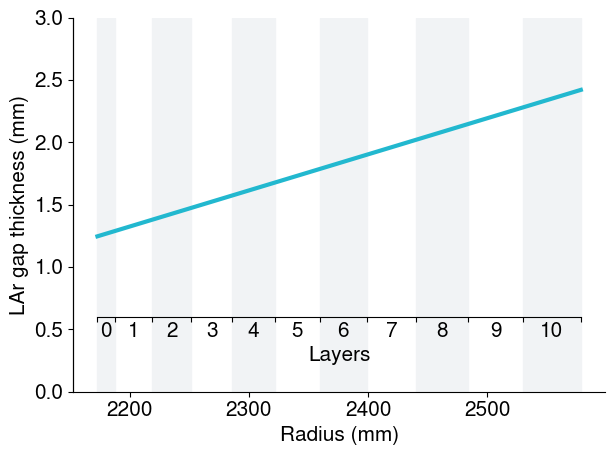

In [26]:
fig, ax = plot_gap_thickness(geo=geo)
plt.show()

# Sketches of the calorimeter concept

In [27]:
def plot_design(geo, show='full'):
    """Main calo design sketch

    show: which part of the design to show. Can be 'full', 'quadrant', 'sketch' or (x1, y1, x2, y2).

    """
    fig = plt.figure(figsize=(10,10), tight_layout=True)
    ax = plt.subplot(1, 1, 1, aspect=1)

    absorbers = []
    sheets = []
    fillers = []
    electrodes = []

    layers = geo.layers_on_electrode()

    for i in range(geo.n_planes):
        # we create rectangles at phi=0 with 50deg angle, then we rotate them by the correct amount
        t_el = transforms.Affine2D().rotate(i*geo.dphi)
        r_el = Rectangle((geo.embarrel_rmin, -geo.readout_thickness/2), geo.plane_length,
                geo.readout_thickness, angle=np.degrees(geo.alpha), rotation_point=(geo.embarrel_rmin, 0),
                transform=t_el)
        electrodes.append(r_el)
        t_abs = transforms.Affine2D().rotate((i+1/2)*geo.dphi)
        r_abs = Rectangle((geo.embarrel_rmin+layers[0], -geo.pb_thickness/2),
                geo.plane_length-layers[0], geo.pb_thickness, angle=np.degrees(geo.alpha),
                rotation_point=(geo.embarrel_rmin, 0), transform=t_abs)
        absorbers.append(r_abs)
        r_fill = Rectangle((geo.embarrel_rmin, -geo.pb_thickness/2), layers[0], geo.pb_thickness,
                angle=np.degrees(geo.alpha), rotation_point=(geo.embarrel_rmin, 0), transform=t_abs)
        fillers.append(r_fill)
        r_sheet1 = Rectangle((geo.embarrel_rmin, -geo.absorber_thickness/2),
                geo.plane_length, geo.sheet_thickness, angle=np.degrees(geo.alpha),
                rotation_point=(geo.embarrel_rmin, 0), transform=t_abs)
        r_sheet2 = Rectangle((geo.embarrel_rmin, +geo.pb_thickness/2),
                geo.plane_length, geo.sheet_thickness, angle=np.degrees(geo.alpha),
                rotation_point=(geo.embarrel_rmin, 0), transform=t_abs)
        sheets.append(r_sheet1)
        sheets.append(r_sheet2)

    lar_front = geo.bar_cryo_ecal_rmin + geo.cryo_barrel_front
    lar_back = geo.bar_cryo_ecal_rmax - geo.cryo_barrel_back

    lar_bath = Annulus((0, 0), lar_back, width = lar_back - lar_front, color=colors['cyan'][2])

    cryo_front_cold = Annulus((0, 0), lar_front, width = geo.cryo_barrel_front_cold)
    # cheat a bit on this placement
    cryo_front_warm = Annulus((0, 0), geo.bar_ecal_rmin + geo.cryo_barrel_front_warm,
            width = geo.cryo_barrel_front_warm)
    cryo_back_cold = Annulus((0, 0), lar_back+geo.cryo_barrel_back_cold, width = geo.cryo_barrel_back_cold)
    cryo_back_warm = Annulus((0, 0), geo.bar_cryo_ecal_rmax, width = geo.cryo_barrel_back_warm)
    cryo_walls = [cryo_front_cold, cryo_front_warm, cryo_back_cold, cryo_back_warm]

    solenoid = Annulus((0, 0), geo.bar_cryo_ecal_rmax-geo.cryo_barrel_back_warm, width = geo.solenoid_barrel,
            color=colors['orange'][3])

    #envelope = Annulus((0, 0), geo.bar_ecal_rmax, width = geo.bar_ecal_rmax - geo.bar_ecal_rmin,
            #edgecolor='black', linestyle='--', facecolor='w')

    #ax.add_artist(envelope)
    ax.add_artist(lar_bath)
    ax.add_artist(solenoid)

    pc_absorbers = PatchCollection(absorbers, color=colors['gray'][4]) #, alpha=0.4)
    pc_electrodes = PatchCollection(electrodes, color=colors['green'][4])
    pc_cryo = PatchCollection(cryo_walls, color=colors['gray'][2])
    pc_fillers = PatchCollection(fillers, color=colors['gray'][1])
    pc_sheets = PatchCollection(sheets, color=colors['gray'][5])
    ax.add_collection(pc_cryo)
    ax.add_collection(pc_absorbers)
    ax.add_collection(pc_fillers)
    ax.add_collection(pc_sheets)
    ax.add_collection(pc_electrodes)

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    if show == 'quadrant':
            ax.set_xlim(0, geo.bar_ecal_rmax)
            ax.set_ylim(0, geo.bar_ecal_rmax)
            ax.spines.right.set_visible(False)
            ax.spines.top.set_visible(False)
    elif show == 'full':
            ax.set_xlim(-geo.bar_ecal_rmax, geo.bar_ecal_rmax)
            ax.set_ylim(-geo.bar_ecal_rmax, geo.bar_ecal_rmax)
            ax.spines.bottom.set_position(('data',0))
            ax.spines.left.set_position(('data',0))
            ax.spines.right.set_visible(False)
            ax.spines.top.set_visible(False)
            for label in ax.get_xticklabels():
                label.set_path_effects(
                        [path_effects.Stroke(linewidth=2, foreground="white"), path_effects.Normal()])
            for label in ax.get_yticklabels():
                label.set_path_effects(
                        [path_effects.Stroke(linewidth=2, foreground="white"), path_effects.Normal()])

    elif type(show) is tuple:
            (x1, y1, x2, y2) = show
            ax.set_xlim(x1, x2)
            ax.set_ylim(y1, y2)

    elif show == 'sketch':
            @ticker.FuncFormatter
            def major_formatter(x, pos):
                return f'{x/10:.1f} cm'
            ax.set_xlim(1700, 2780)
            ax.set_ylim(0, 600)
            ax.set_xlabel('')
            ax.yaxis.set_visible(False)
            ax.spines[['left', 'right', 'top']].set_visible(False)
            ax.xaxis.set_major_formatter(major_formatter)
            ax.xaxis.set_major_locator(ticker.FixedLocator([geo.bar_ecal_rmin,
                geo.embarrel_rmin, geo.embarrel_rmax, geo.bar_ecal_rmax]))
            ax.tick_params(labelsize='x-small')

            xtext = 1800
            xbend = 2030
            def my_annotate(text, xy, ytext):
                t = ax.annotate("", xy=xy, xytext=(xbend, ytext),
                        arrowprops=dict(
                            arrowstyle="->",
                            color="black",
                            shrinkA=0,
                            shrinkB=0,
                            linewidth=1.25,
                            )
                        )
                t.arrow_patch.set_path_effects(
                        [path_effects.Stroke(linewidth=5, foreground="white"), path_effects.Normal()]
                        )
                t = ax.annotate(text, xy=(xbend, ytext), xytext=(xtext, ytext),
                        va='center',
                        arrowprops=dict(
                            arrowstyle="-",
                            color="black",
                            linewidth=1.25,
                            shrinkA=0,
                            shrinkB=0.1,
                            relpos=(1, 0.5),
                            )
                        )

            my_annotate("Steel sheet", xy=geo.pos_sheet(200, 8), ytext=500)
            my_annotate("Lead absorber", xy=geo.pos_absorber(150, 8), ytext=450)
            my_annotate("Filler (pre-sampler)", xy=geo.pos_absorber(10, 9), ytext=400)
            my_annotate("Noble liquid", xy=geo.pos_gap(80, 8), ytext=350)
            my_annotate("Readout electrode", xy=geo.pos_electrode(50, 8), ytext=300)

    fig.tight_layout()
    return fig, ax

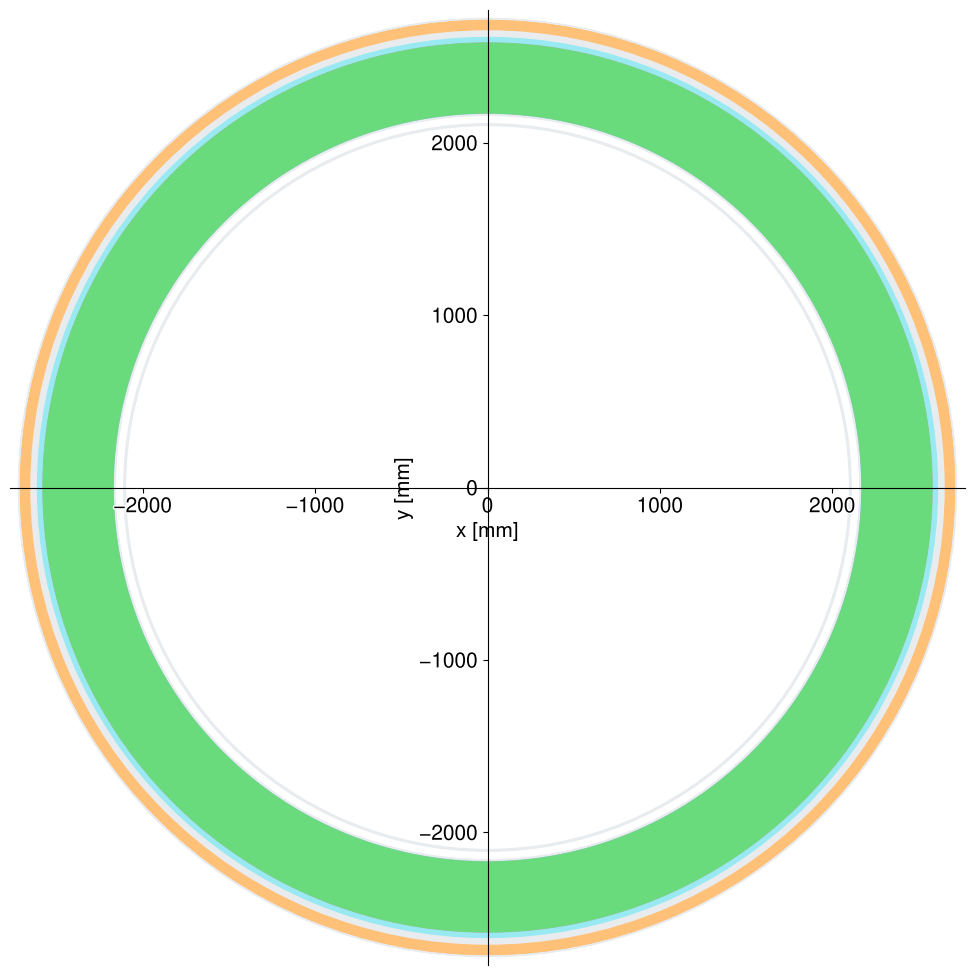

In [28]:
fig, ax = plot_design(geo, show='full')
plt.show()

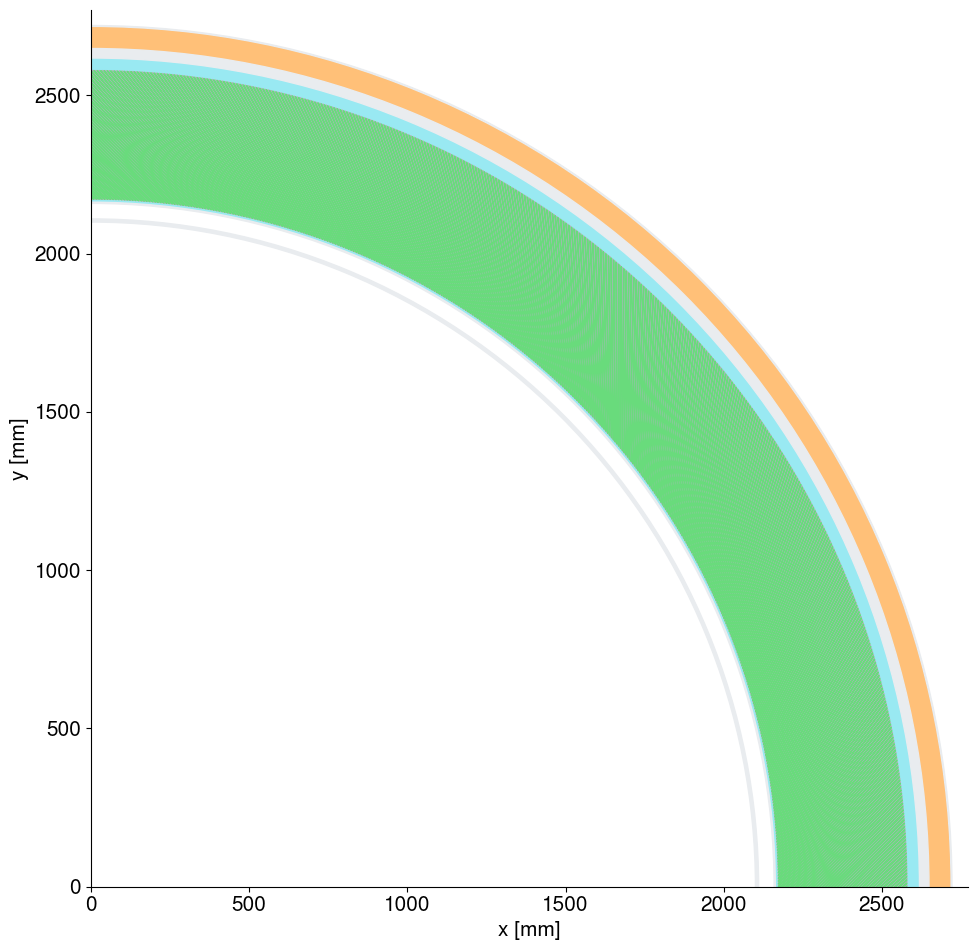

In [29]:
fig, ax = plot_design(geo, show='quadrant')
plt.show()

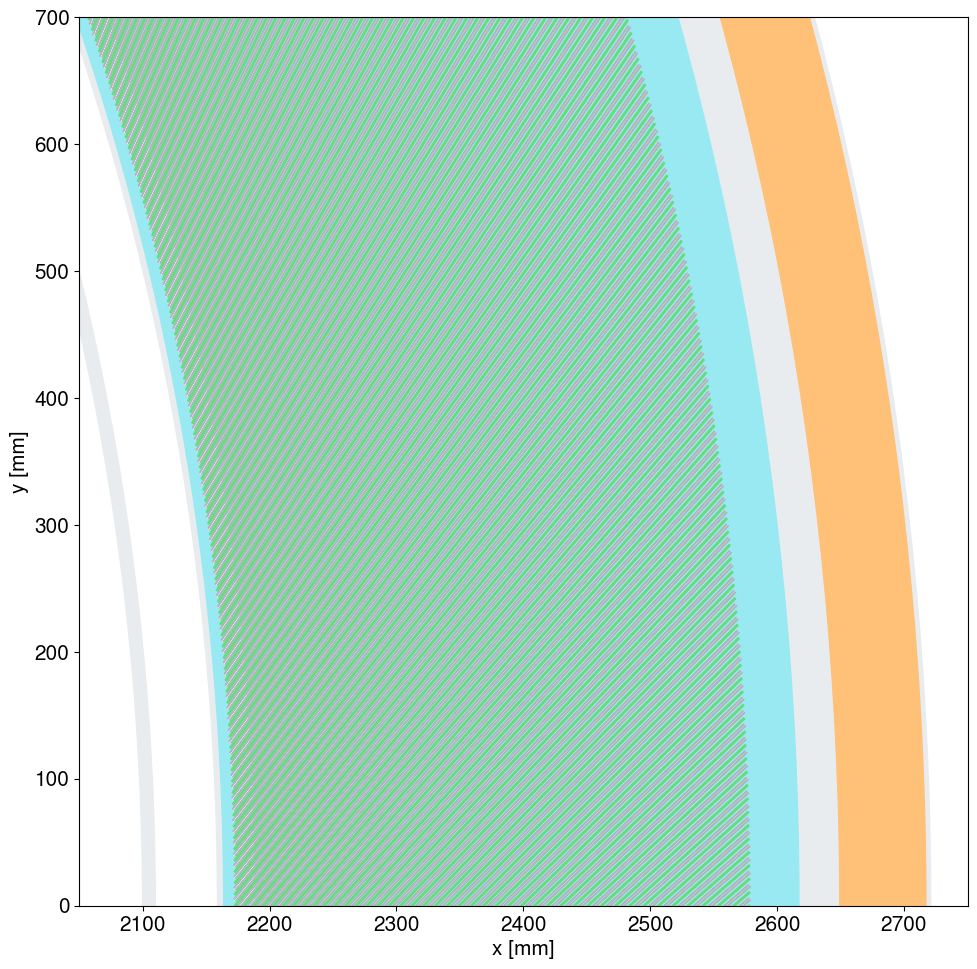

In [30]:
fig, ax = plot_design(geo, show=(2050, 0, 2750, 700))
plt.show()

In [31]:
geo.scale_thicknesses(5.)

Total length of electrode computed from sum of layer lengths (mm): 573.9371
Total length of electrode from geometry (mm): 573.9371507608496


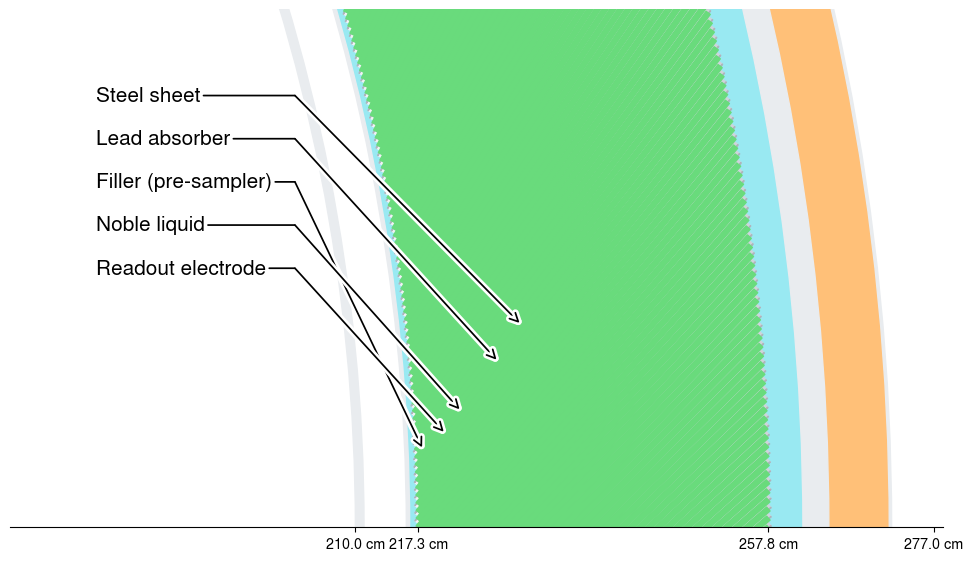

In [32]:
plot_design(geo, show='sketch')
plt.show()

# Sketch of the electrode

400 43 9
R(0) = 217.28000000000003
R(1) = 218.93000000000004
R(2) = 222.29000000000002
R(3) = 225.75000000000003
R(4) = 229.31000000000003
R(5) = 232.99000000000004
R(6) = 236.78000000000003
R(7) = 240.70000000000005
R(8) = 244.75000000000003
R(9) = 248.95000000000005
R(10) = 253.3
R(11) = 257.82000000000005


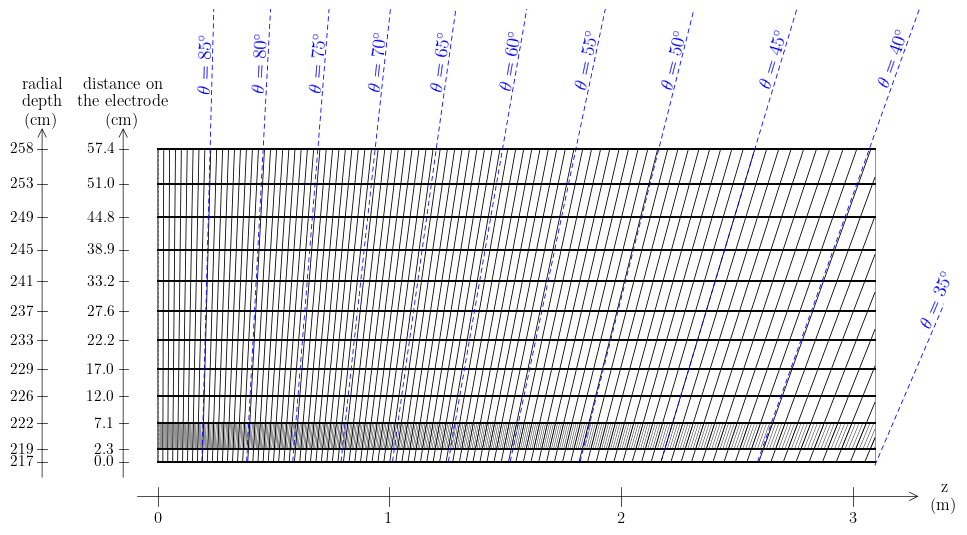

In [33]:
# -------------------
# GEOMETRY PARAMETERS
# -------------------

# geometry
# Lengths of layers on the electrode (cm)
dL = [2.33, 4.76, 4.9,  5.05, 5.2,  5.37, 5.55, 5.74, 5.94, 6.16, 6.4 ]
# Lengths of layers scaled to calo depth (cm)
dR = [1.65, 3.36, 3.46, 3.56, 3.68, 3.79, 3.92, 4.05, 4.2,  4.35, 4.52]

# z extent of barrel (cm)
zmin = 0
zmax = geo.embarrel_dz/10.

# r extend of barrel
# rmin = 217.28
# rmax = 257.83
rmin = geo.embarrel_rmin/10.
rmax = geo.embarrel_rmax/10

# number of layers
nLayers = len(geo.readout_layers)

# theta granularity
grid_size_theta = geo.grid_size_theta
offset_theta = geo.offset_theta

# ------------
# GLOBAL STYLE
# ------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})


# ------------------
# GRAPHIC PARAMETERS
# ------------------
ratio = 0.3
xscale = 0.3

# line thickness
LW_THIN = 0.3      # TikZ "very thick" ≈ 0.5–0.8pt
LW_MID  = 0.6      # linee medie
LW_HEAVY = 1.4     # linee layer (8pt TikZ ma visivamente compresso da xscale)
AX_LW = 0.5          # ~ TikZ line width 2pt
TICK_LW = 0.5        # tick più sottile
TICK_LEN = 4         # molto più corto
FONT_SIZE = 11

# ----------------
# HELPER FUNCTIONS
# ----------------
def X(x):
    return x * xscale

def Y(y):
    return y

# inner radius of layer i
def R(i):
    return rmin + sum(dR[:i])

# length along electrode for layer i
def L(i):
    return sum(dL[:i])

def theta_bin(theta):
    return int(np.round((theta - offset_theta + grid_size_theta*0.5)/grid_size_theta))

def theta(theta_bin):
    return (offset_theta - grid_size_theta*0.5 + theta_bin*grid_size_theta)

# ---------------------------
# DERIVED GEOMETRY PARAMETERS
# ---------------------------
theta_halfbarrel = theta_bin(np.pi/2)
theta_fullcoverage = theta_bin(np.atan2(rmax, zmax))
theta_min = theta_bin(np.atan2(rmin, zmax))
theta_fullcoverage_strips = theta_bin(np.atan2(R(2), zmax))
theta_min_strips = theta_bin(np.atan2(R(1), zmax))
theta_min = theta_bin(np.atan2(rmin, zmax))

print(theta_halfbarrel, theta_fullcoverage, theta_min)



# ----------------------------
# FIGURE
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)

ax.set_aspect("equal")

# ---------------- Z axis ----------------
ymid = rmin - 15 * ratio

ax.annotate(
    "",
    xy=(X(zmax + 20), ymid),
    xytext=(X(zmin - 10), ymid),
    arrowprops=dict(arrowstyle='->', lw=AX_LW, color='black'),
    annotation_clip=False,
 )

ax.text(
    X(zmax + 30),
    ymid,
    "z\n(m)",
    fontsize=12,
    ha="center",
    va="center"
)

# ticks z
for z in range(0, 4):
    x = X(zmin + 100 * z)
    ax.plot(
        [x, x],
        [ymid - TICK_LEN * ratio, ymid + TICK_LEN * ratio],
        color="black",
        lw=TICK_LW
    )

    ax.text(
        x,
        ymid - (TICK_LEN + 2) * ratio,
        str(z),
        ha="center",
        va="top",
        fontsize=12
    )

# ---------------- radial depth axis ----------------

xmid = zmin - 50
ax.annotate(
    "",
    xy=(X(xmid), rmax + 10 * ratio),
    xytext=(X(xmid), rmin - 8 * ratio),
    arrowprops=dict(arrowstyle='->', lw=AX_LW, color='black')
)

ax.text(
    X(xmid),
    rmax + 20 * ratio,
     "radial\ndepth\n(cm)",
     ha="center",
     va="center",
     fontsize=12
)

# ticks radial
for i in range(0, nLayers + 1):
    y = R(i)
    print(f"R({i}) = {y}")
    ax.plot(
        [X(xmid - TICK_LEN/2), X(xmid + TICK_LEN/2)],
        [y, y],
        color="black",
        lw=TICK_LW
    )

    ax.text(
        X(xmid - TICK_LEN/2 - 2),
        y,
        f"{y:.0f}",
        ha="right",
        va="center",
        fontsize=FONT_SIZE
    )


# ---------------- electrode distance axis ----------------
xmid = zmin - 15
ax.annotate(
    "",
    xy=(X(xmid), rmax + 10 * ratio),
    xytext=(X(xmid), rmin - 8 * ratio),
    arrowprops=dict(arrowstyle='->', lw=AX_LW, color='black')
)

ax.text(
    X(xmid),
    rmax + 20*ratio,
    "distance on\nthe electrode\n(cm)",
    ha="center",
    va="center",
    fontsize=12
)

# ticks electrode
for i in range(0, nLayers + 1):
    y = R(i)
    l = L(i)
    ax.plot(
        [X(xmid - TICK_LEN/2), X(xmid + TICK_LEN/2)],
        [y, y],
        color="black",
        lw=TICK_LW
    )

    ax.text(
        X(xmid - TICK_LEN/2 - 2),
        y,
        f"{l:.1f}",
        ha="right",
        va="center",
        fontsize=FONT_SIZE
    )

# =========================================================
# 1. CALORIMETER FRAME (gray box)
# =========================================================
ax.plot([X(zmin), X(zmax)], [rmin, rmin], color="gray", lw=LW_MID)
ax.plot([X(zmin), X(zmax)], [rmax, rmax], color="gray", lw=LW_MID)
ax.plot([X(zmin), X(zmin)], [rmin, rmax], color="gray", lw=LW_MID, linestyle="--")
ax.plot([X(zmax), X(zmax)], [rmin, rmax], color="gray", lw=LW_MID)

# =========================================================
# 2. LAYERS (horizontal thick lines)
# =========================================================

ax.plot([X(zmin), X(zmax)], [rmin, rmin], lw=LW_HEAVY, color="black")
for i in range(0, nLayers + 1):
    y = R(i)
    ax.plot([X(zmin), X(zmax)], [y, y], lw=LW_HEAVY, color="black")

# =========================================================
# 3. THETA GRID IN LAYER 1 (thin lines)
# =========================================================

for thetabin in range(theta_min_strips, theta_halfbarrel):
    # tan(theta)
    t = np.tan(theta(thetabin))
    # y1 = Rmin(layer1)
    Y1 = rmin + dR[0]
    # x at y1 and y2, given theta
    X1 = X(Y1 / t)

    if thetabin < theta_fullcoverage_strips:
        # range within partial acceptance
        # X2 = zmax, Y2 = corresponding r for given theta
        X2 = X(zmax)
        Y2 = zmax * t
    else:
        # range within full acceptance
        # Y2 = Rmax(layer1), X2 = corresponding z for given theta
        Y2 = Y1 + dR[1]
        X2 = X(Y2 / t)
    # draw the line
    ax.plot([X1, X2], [Y1, Y2], lw=LW_THIN, color="black")

# =========================================================
# 4. MERGED THETA LINES in ALL LAYERS (thick)
# =========================================================

for thetabin in range(int(theta_min/4)+1, int(theta_halfbarrel/4)+1):
    # tan(theta)
    t = np.tan(theta(thetabin*4))
    # y1: R=Rmin; x = corresponding z at given theta
    Y1 = rmin
    X1 = X(rmin / t)
    if thetabin < int(theta_fullcoverage/4)+1:
        # range with partial acceptance
        # y at given theta, z=zmax
        Y2 = zmax * t
        X2 = X(zmax)
    else:
        # range within full acceptance
        Y2 = rmax
        X2 = X(rmax / t)
    # draw the line
    ax.plot([X1, X2], [Y1, Y2], lw=LW_MID, color="black")


# =========================================================
# 5. BLUE DASHED THETA LINES EVERY 5 DEGREES
# =========================================================
dtheta = 5  # degrees
drend = dR[nLayers-1] * 4.0

for thetabin in range(0, 18):
    # theta (degrees)
    th = thetabin * dtheta
    # tan(theta)
    t = np.tan(np.deg2rad(th))

    if t < rmin/zmax and thetabin!=7:
        # outside acceptance - make an exception for 35 degrees which is very close to edge...
        continue
    elif t<rmax/zmax:
        # in partial acceptance
        xend = zmax+30
        X1 = X(zmax)
        X2 = X(xend)
        Y1 = zmax * t
        Y2 = xend * t
    else:
        # in full acceptance
        # x at given theta, R=Rmin
        X1 = X(rmin / t)
        Y1 = rmin
        # x at given theta, R=Rmax + drend
        X2 = X((rmax + drend) / t)
        Y2 = rmax + drend

    # draw the line
    ax.plot(
        [X1, X2],
        [Y1, Y2],
        color="blue",
        lw=LW_MID,
        linestyle=(0, (6, 4))
    )
    # move labels along the blue line
    shift = 0.82  # 1 = at end, 0 = at start
    x_text = X1 + shift * (X2 - X1)
    y_text = Y1 + shift * (Y2 - Y1)
    # calculate little shift along perpendicular direction to have small gap between text and line
    dx = X2 - X1
    dy = Y2 - Y1
    norm = np.hypot(dx, dy)
    ox = -dy / norm
    oy = dx / norm
    offset = 2
    x_text += offset * ox
    y_text += offset * oy
    # calculate rotation angle so that labels are parallel to lines
    angle = np.degrees(np.arctan2(dy, dx))
    # write the text
    ax.text(
        x_text,
        y_text,
        rf"$\theta={th}^\circ$",
        rotation=angle,
        fontsize=14,
        color="blue"
    )

# =========================================================
# 6. FINAL VIEW SETTINGS
# =========================================================
ax.set_xlim(X(zmin-62), X(zmax + 30))
ax.set_ylim(rmin - (15 + TICK_LEN + 5) * ratio, rmax + drend)
ax.axis("off")

plt.tight_layout()
plt.show()
plt.savefig("readout.pdf", bbox_inches="tight", pad_inches=0.02)